In [6]:
import pandas as pd
df = pd.read_csv("datasetNEW.csv")  # header=0 est implicite ici

In [7]:
print(df.columns)

Index(['conca_bin', 'conca', 'PEG10', 'CRIM1', 'SMYD2', 'FABP4', 'FSD1L',
       'PEG3', 'PLCB4', 'RHOBTB1', 'UTRN', 'KIT', 'HDAC11', 'SEMA7A', 'GREB1',
       'ANKRD50', 'ZNF233', 'CORO2A'],
      dtype='object')


In [8]:
df = df.drop(columns=["conca"])
print(df.columns)

Index(['conca_bin', 'PEG10', 'CRIM1', 'SMYD2', 'FABP4', 'FSD1L', 'PEG3',
       'PLCB4', 'RHOBTB1', 'UTRN', 'KIT', 'HDAC11', 'SEMA7A', 'GREB1',
       'ANKRD50', 'ZNF233', 'CORO2A'],
      dtype='object')


In [9]:
y = df["conca_bin"]
X = df.drop(columns=["conca_bin"])

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Normaliser les données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Séparer en train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

from tensorflow.keras import Input

model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # sortie binaire

2026-06-09 13:39:05.265773: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-09 13:39:05.723436: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781005145.797316   66124 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781005145.838951   66124 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-09 13:39:06.150934: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entraîner le modèle
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7430 - loss: 0.4730 - val_accuracy: 0.9616 - val_loss: 0.1000
Epoch 2/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 1s 960us/step - accuracy: 0.9532 - loss: 0.1177 - val_accuracy: 0.9642 - val_loss: 0.0872
Epoch 3/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 1s 885us/step - accuracy: 0.9616 - loss: 0.0976 - val_accuracy: 0.9663 - val_loss: 0.0840
Epoch 4/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 1s 892us/step - accuracy: 0.9606 - loss: 0.1001 - val_accuracy: 0.9690 - val_loss: 0.0822
Epoch 5/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 1s 887us/step - accuracy: 0.9622 - loss: 0.0936 - val_accuracy: 0.9686 - val_loss: 0.0797
Epoch 6/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 1s 886us/step - accuracy: 0.9631 - loss: 0.0942 - val_accuracy: 0.9697 - val_loss: 0.0814
Epoch 7/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 1s 972us/step - accuracy: 0.9661 - loss: 0.0863 - val_accuracy: 0.9691 - val_loss: 0.0801
Epoch 8/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 1s 916us/step - accuracy: 0.9650 - loss: 0.0885 - va

In [16]:
# Évaluer sur le test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.3f}")

Test Accuracy: 0.970


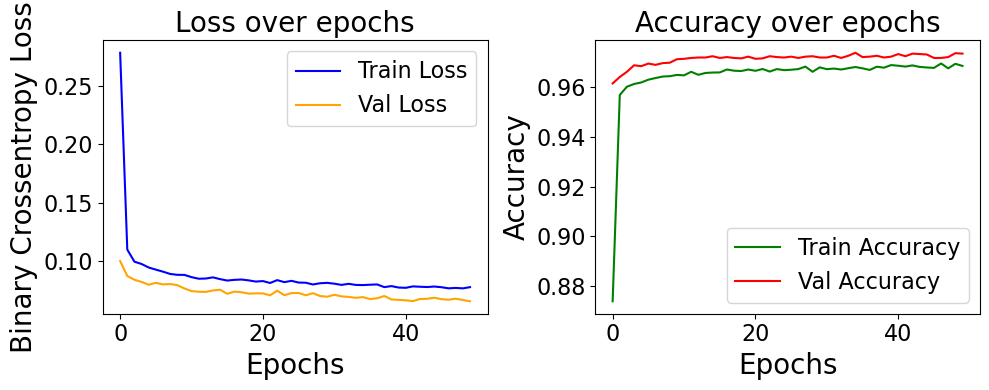

In [17]:

import matplotlib.pyplot as plt

# Courbes de perte et précision
plt.figure(figsize=(10, 4))

# Sous-figure 1 : perte
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Loss over epochs', fontsize=20)
plt.xlabel('Epochs', fontsize=20)
plt.ylabel('Binary Crossentropy Loss', fontsize=20)
plt.legend(fontsize=16)
plt.tick_params(axis='both', labelsize=16)

# Sous-figure 2 : précision
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='red')
plt.title('Accuracy over epochs', fontsize=20)
plt.xlabel('Epochs', fontsize=20)
plt.ylabel('Accuracy', fontsize=20)
plt.legend(fontsize=16)
plt.tick_params(axis='both', labelsize=16)

plt.tight_layout()
plt.savefig("learning.jpeg", dpi=600, format='jpeg', bbox_inches='tight')
plt.show()
plt.close()


In [18]:

## rOC
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
# Prédire les probabilités (pas les classes)
y_pred_proba = model.predict(X_test).ravel()
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)


384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 478us/step


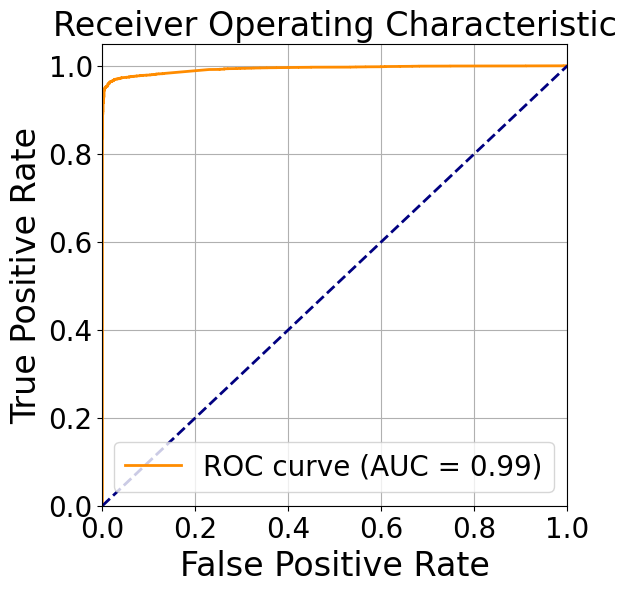

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # ligne diagonale
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Axes et titre avec police taille 24
plt.xlabel('False Positive Rate', fontsize=24)
plt.ylabel('True Positive Rate', fontsize=24)
plt.title('Receiver Operating Characteristic', fontsize=24)

# Légende et ticks
plt.legend(loc="lower right", fontsize=20)
plt.tick_params(axis='both', labelsize=20)
plt.grid(True)

# Sauvegarde avant affichage
plt.savefig("ROC.jpeg", dpi=600, format='jpeg', bbox_inches='tight')
plt.show()
plt.close()

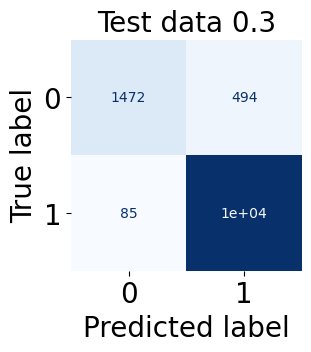

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prédire les classes binaires avec seuil 0.25
y_pred_class = (y_pred_proba >= 0.25).astype(int)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Création de la figure avec axe personnalisé
fig, ax = plt.subplots(figsize=(3, 3))
disp.plot(cmap='Blues', ax=ax, colorbar=False)

# Personnalisation complète
ax.set_title("Test data 0.3", fontsize=20)
ax.set_xlabel("Predicted label", fontsize=20)
ax.set_ylabel("True label", fontsize=20)
ax.tick_params(axis='both', labelsize=20)

# Supprimer les bordures inutiles
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

# Sauvegarde haute résolution
plt.savefig("confusion.jpeg", dpi=600, format='jpeg', bbox_inches='tight')
plt.show()
plt.close()


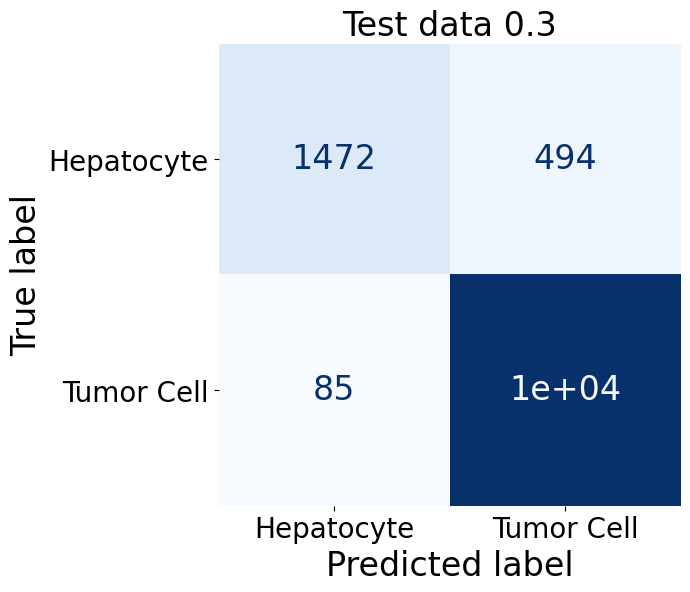

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prédire les classes binaires avec seuil 0.25
y_pred_class = (y_pred_proba >= 0.25).astype(int)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_class)

# Définir les labels biologiques
labels_bio = ["Hepatocyte", "Tumor Cell"]

# Créer l'affichage avec labels personnalisés
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_bio)

# Création de la figure
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, colorbar=False)

# Personnalisation des axes
ax.set_title("Test data 0.3", fontsize=24)
ax.set_xlabel("Predicted label", fontsize=24)
ax.set_ylabel("True label", fontsize=24)
ax.tick_params(axis='both', labelsize=20)

# Supprimer les bordures inutiles
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

# 🔠 Agrandir les chiffres dans les cases
for text_element in disp.text_.ravel():
    text_element.set_fontsize(24)

# Sauvegarde haute résolution
plt.savefig("confusion.jpeg", dpi=600, format='jpeg', bbox_inches='tight')
plt.show()
plt.close()

In [23]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred_class, digits=3)

with open("classification_report.txt", "w") as f:
    f.write(report)


In [24]:
## rapport de classification
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_class, digits=3))

              precision    recall  f1-score   support

           0      0.945     0.749     0.836      1966
           1      0.954     0.992     0.972     10321

    accuracy                          0.953     12287
   macro avg      0.950     0.870     0.904     12287
weighted avg      0.953     0.953     0.951     12287



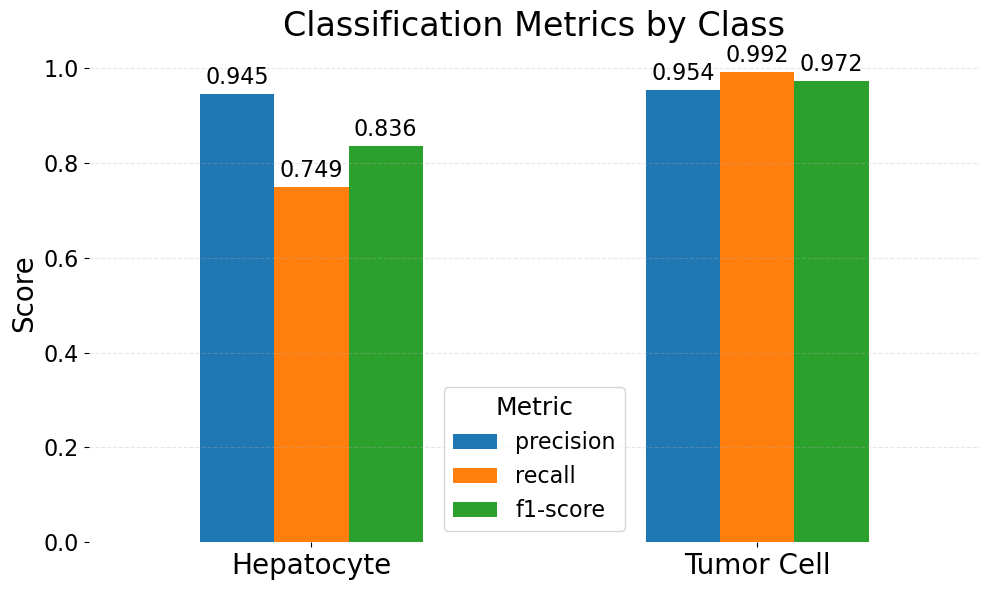

In [25]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import pandas as pd

# Générer le rapport sous forme de dictionnaire
report_dict = classification_report(y_test, y_pred_class, output_dict=True, digits=3)

# Reformatage avec labels biologiques
label_map = {'0': 'Hepatocyte', '1': 'Tumor Cell'}
scores = ['precision', 'recall', 'f1-score']
data = {label_map[k]: [report_dict[k][s] for s in scores] for k in ['0', '1']}
df_scores = pd.DataFrame(data, index=scores)

# Création du barplot
fig, ax = plt.subplots(figsize=(10, 6))
df_scores.T.plot(kind='bar', ax=ax, rot=0, color=['#1f77b4', '#ff7f0e', '#2ca02c'])

# Thème minimaliste
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Personnalisation
ax.set_title("Classification Metrics by Class", fontsize=24)
ax.set_ylabel("Score", fontsize=20)
ax.set_ylim(0.0, 1.05)
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=16)
ax.legend(title="Metric", fontsize=16, title_fontsize=18)

# Annotations sur les barres
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f"{height:.3f}", ha='center', va='bottom', fontsize=16)

plt.tight_layout()
plt.savefig("classification_barplots.jpeg", dpi=600, format='jpeg', bbox_inches='tight')
plt.show()
plt.close()


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy test data:", accuracy_score(y_test, y_pred_class))
print("Precision test data:", precision_score(y_test, y_pred_class))
print("Recall test data:", recall_score(y_test, y_pred_class))
print("F1 Score test data:", f1_score(y_test, y_pred_class))
     

Accuracy test data: 0.9528770244974363
Precision test data: 0.9539608574091333
Recall test data: 0.991764363918225
F1 Score test data: 0.9724953683910503


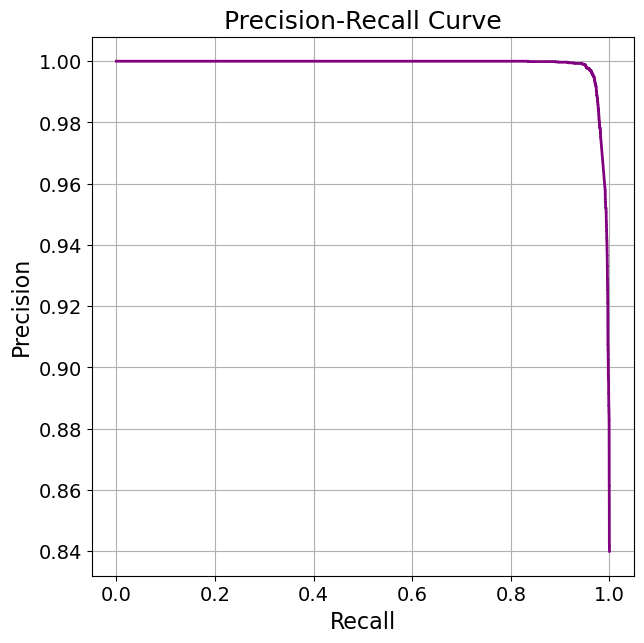

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Augmenter la taille de police globale
plt.rcParams.update({
    "font.size": 16,        # taille de police générale
    "axes.titlesize": 18,   # titre
    "axes.labelsize": 16,   # labels axes
    "xtick.labelsize": 14,  # ticks
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 7))
plt.plot(recall, precision, color='purple', linewidth=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)

plt.savefig("prcurve_bigfont.jpeg", dpi=600, format='jpeg', bbox_inches='tight')
plt.show()
plt.close()

     

In [34]:
## youden index f-max
from sklearn.metrics import f1_score

thresholds = sorted(set(y_pred_proba))
best_f1 = 0
best_thresh = 0

for t in thresholds:
    preds = (y_pred_proba >= t).astype(int)
    score = f1_score(y_test, preds)
    if score > best_f1:
        best_f1 = score
        best_thresh = t

print(f"Seuil optimal (F1-max): {best_thresh:.3f} avec F1 = {best_f1:.3f}")



Seuil optimal (F1-max): 0.493 avec F1 = 0.982


In [35]:
## save model
model.save("mon_modele.h5")


In [4]:
## reload model

from tensorflow.keras.models import load_model

# Charger le modèle sauvegardé
model = load_model("mon_modele.h5")
     

2026-06-09 14:44:43.767648: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-09 14:44:43.787919: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781009083.814007  515196 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781009083.822668  515196 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-09 14:44:43.851190: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [37]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 40.3 MB/s  0:00:016m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 4.9 MB/s  0:00:000m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 17.8 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 6.1 MB/s  0:00:0136m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 24.6 MB/s  0:00:016m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  0/11 [tqdm]  WARNING: The script tqdm is installed in '/shared/home/cdesterke/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [shap]2m10/11 [shap]]]learn]]


In [41]:
import sys
print(sys.version)
##### terminal
## source /shared/software/miniconda_deployment/bin/activate python-3.9
## which python
## python -m ipykernel install --user --name python39-real --display-name "Python 3.9 (real)"
## select python 3.9 real



3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12) 
[GCC 13.3.0]


In [43]:
import sys
!{sys.executable} -m pip install shap




Defaulting to user installation because normal site-packages is not writeable
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 999.3/999.3 kB 4.9 MB/s  0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 16.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 MB 32.7 MB/s  0:00:016m0:00:0100:01
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]4/5 [shap]]ickle]


In [43]:
import sys
!{sys.executable} -m pip install shap




Defaulting to user installation because normal site-packages is not writeable
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 999.3/999.3 kB 4.9 MB/s  0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 16.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 MB 32.7 MB/s  0:00:016m0:00:0100:01
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]4/5 [shap]]ickle]


In [43]:
import sys
!{sys.executable} -m pip install shap




Defaulting to user installation because normal site-packages is not writeable
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 999.3/999.3 kB 4.9 MB/s  0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 16.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 MB 32.7 MB/s  0:00:016m0:00:0100:01
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]4/5 [shap]]ickle]


In [2]:
import shap
print(shap.__version__)


0.49.1


In [46]:
import sys
print(sys.executable)


/shared/software/miniconda_deployment/envs/python-3.9/bin/python


PermutationExplainer explainer: 12288it [07:42, 26.29it/s]                           
/tmp/slurm_cdesterke_66776713.tmp/ipykernel_515196/221133627.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=X.columns)


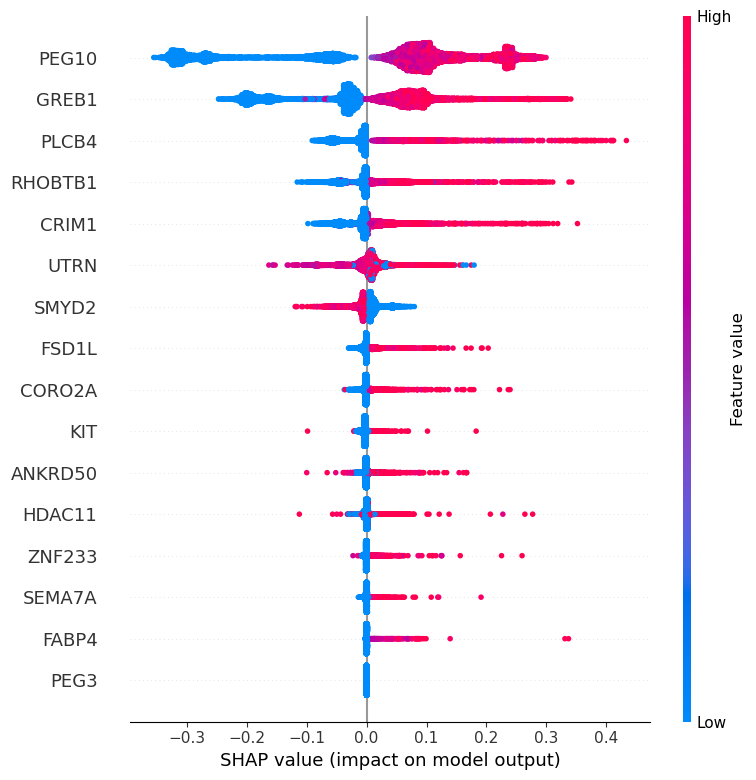

In [11]:
import shap
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Résumé global
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

/tmp/slurm_cdesterke_66776713.tmp/ipykernel_515196/543658566.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=X.columns, show=False)


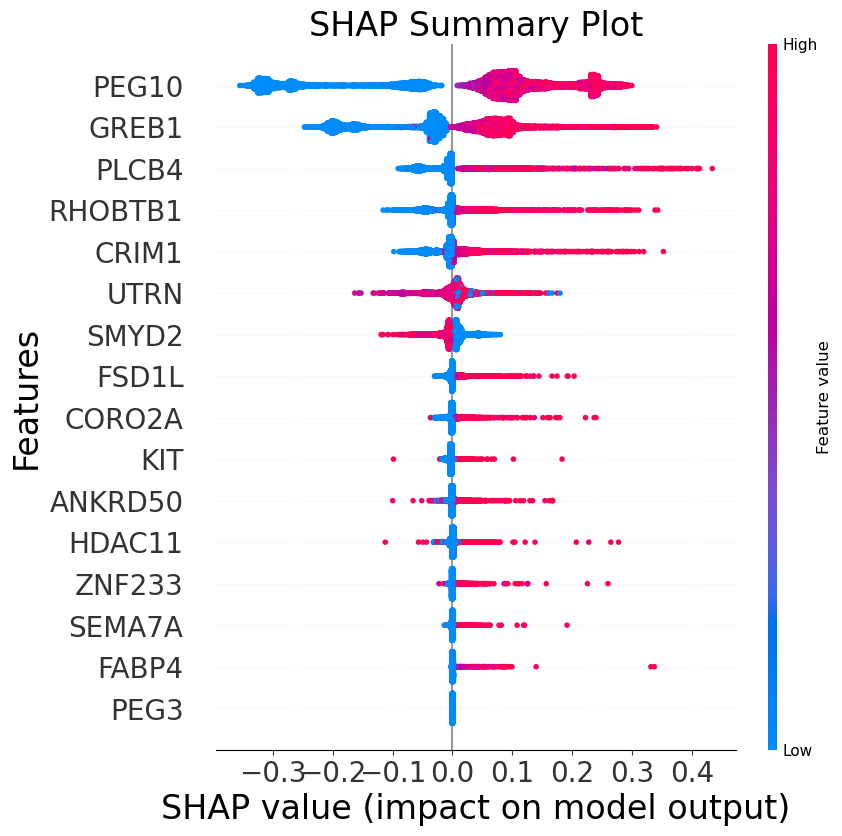

In [12]:

import shap
import matplotlib.pyplot as plt

# Générer le résumé SHAP sans affichage immédiat
shap.summary_plot(shap_values, X_test, feature_names=X.columns, show=False)

# 🔠 Personnaliser la taille de police
plt.title("SHAP Summary Plot", fontsize=24)
plt.xlabel("SHAP value (impact on model output)", fontsize=24)
plt.ylabel("Features", fontsize=24)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Sauvegarder en JPEG haute résolution
plt.savefig("shap_summary.jpeg", dpi=600, format='jpeg', bbox_inches='tight')
plt.show()
plt.close()